# Tarea 09
#### Nombre: David Alejandro Díaz Pineda

### 1)Para  cada  uno  de  los  siguientes  sistemas  lineales,  obtenga,  de  ser  posible,  una  solución  con  métodos  gráficos. Explique los resultados desde un punto de vista geométrico. 

a. <br>$x_1 + 2x_2 = 0$<br> $x_1 - x_2$

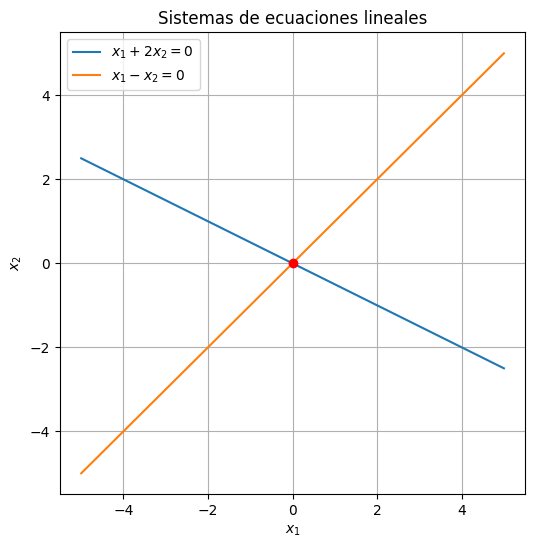

In [70]:
import numpy as np
import matplotlib.pyplot as plt


x1 = np.linspace(-5, 5, 400)

x2_eq1 = -0.5 * x1
x2_eq2 = x1

plt.figure(figsize=(6,6))
plt.plot(x1, x2_eq1, label=r"$x_1 + 2x_2 = 0$")
plt.plot(x1, x2_eq2, label=r"$x_1 - x_2 = 0$")

# Intersección

plt.scatter(0, 0, color = "red", zorder=5)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Sistemas de ecuaciones lineales")
plt.legend()
plt.grid(True)
plt.show()

El sistema tiene una única solución, ya que las rectas se intersecan en un único punto el cuál representa la solución

b. <br> $x_1 + 2x_2=3$ <br> $-2x_1 - 4x_2 = 6$

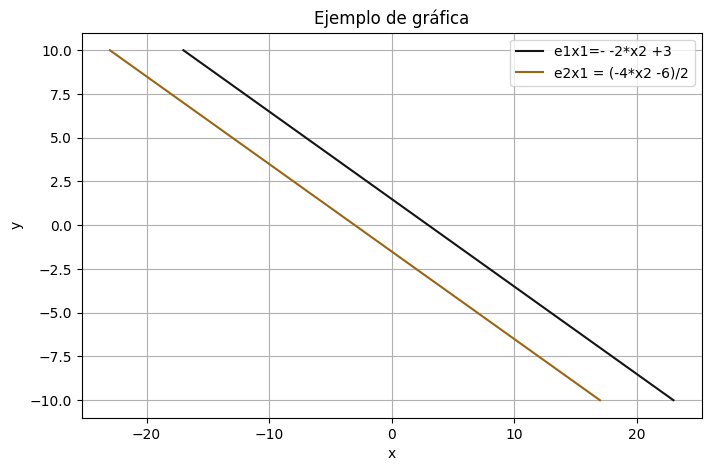

In [71]:
x2 = np.linspace(-10, 10, 100)
x1e1= 3 - 2* x2
x1e2=  (-4*x2 -6)/2

plt.figure(figsize=(8, 5))
plt.plot(x1e1, x2,color="#141414", label='e1x1=- -2*x2 +3')
plt.plot(x1e2, x2, color="#9C6512", label='e2x1 = (-4*x2 -6)/2')
plt.title('Ejemplo de gráfica')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Ambas rectan no intersecan en ningún punto, son paralelas y por lo tanto no hay raíz

c. <br> $2x_1 + x_2 = -1$ <br> $x_1 + x_2 = 2$ <br> $x_1 - 3x_2 = 5$

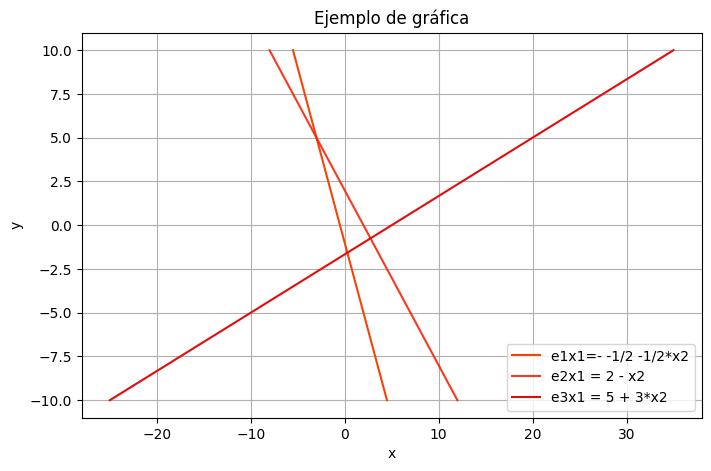

In [72]:
x2 = np.linspace(-10, 10, 100)
x1e1= -1/2 -1/2*x2
x1e2=  2 - x2
x1e3= 5 + 3*x2

plt.figure(figsize=(8, 5))
plt.plot(x1e1, x2,color="#F44505", label='e1x1=- -1/2 -1/2*x2')
plt.plot(x1e2, x2, color="#F72409E6", label='e2x1 = 2 - x2')
plt.plot(x1e3, x2, color="#E20C0C", label='e3x1 = 5 + 3*x2')
plt.title('Ejemplo de gráfica')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

No existe un punto en el que las tres funciones itersecan por lo que el sistema no tiene solución,

d. <br> $2x_1 + x_2 + x_3 = 1$ <br> $2x_1 + 4x_2 - x_3 = -1$ 

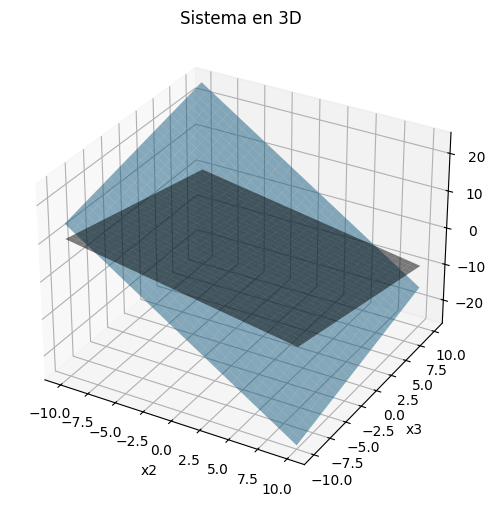

In [73]:
from mpl_toolkits.mplot3d import Axes3D

x2, x3 = np.meshgrid(np.linspace(-10,10,30), np.linspace(-10,10,30))

x1e1 = (1 - x2 - x3 ) * 0.5
x1e2 = (-1 - 4*x2 + x3) * 0.5

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x2, x3, x1e1, alpha=0.5, color="#000000")
ax.plot_surface(x2, x3, x1e2, alpha=0.5, color="#24A7E8"    )

ax.set_xlabel('x2')
ax.set_ylabel('x3')
ax.set_zlabel('x1')
plt.title('Sistema en 3D')
plt.show()

### 2) Utilice la eliminación gaussiana con sustitución hacia atrás y aritmética de redondeo de dos dígitos para resolver los siguientes sistemas lineales.  No reordene las ecuaciones. (La solución exacta para cada sistema es  𝑥1 =−1

In [74]:
import numpy as np
import logging
from sys import stdout
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(datetime.now())

def r(x):
    return np.round(x, 2)

def eliminacion_gaussiana(A: np.ndarray | list[list[float | int]]) -> np.ndarray:
    """Resuelve un sistema de ecuaciones lineales mediante el método de eliminación gaussiana.

    ## Parameters

    ``A``: matriz aumentada del sistema de ecuaciones lineales. Debe ser de tamaño n-by-(n+1), donde n es el número de incógnitas.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """
    if not isinstance(A, np.ndarray):
        logging.debug("Convirtiendo A a numpy array.")
        A = np.array(A)
    assert A.shape[0] == A.shape[1] - 1, "La matriz A debe ser de tamaño n-by-(n+1)."
    n = A.shape[0]
    
    for i in range(0, n - 1 ): #loop por columna
        
        # ---encontrar pivote
        p = None #default, first element
        for pi in range(i, n):
            if A[pi, i] == 0:
                # must be nonzero
                continue
            
            if p is None:
                # first nonzero element
                p = pi
                continue
            
            if abs(A[pi, i] < abs(A[p,i])):
                p = pi
        if p is None:
            # no pivot found.
            raise ValueError("No existe solución única.")

        if p != i:
            # swap rows
            logging.debug(f"Intercambiando filas {i} y {p}")
            _aux = A[i, :].copy()
            A[i, :] = A[p, :].copy()
            A[p, :] = _aux

        # --- Eliminación: loop por fila
        for j in range(i + 1, n):
            m = r( A[j, i] / A[i, i])
            A[j, i:] = r(A[j, i:] - r(m * A[i, i:]))

        logging.info(f"\n{A}")

    if A[n - 1, n - 1] == 0:
        raise ValueError("No existe solución única.")

        print(f"\n{A}")
    # --- Sustitución hacia atrás
    solucion = np.zeros(n)
    solucion[n - 1] =r( A[n - 1, n] / A[n - 1, n - 1])

    for i in range(n - 2, -1, -1):
        suma = 0
        for j in range(i + 1, n):
            suma += r(A[i, j] * solucion[j])
        solucion[i] = r((A[i, n] - suma) / A[i, i])

    return solucion        

[01-06 21:29:10][INFO] 2026-01-06 21:29:10.552545


a. <br> $-x_1 + 4x_2 + x_3 = 8$ <br> <br> $\frac{5}{3}x_1+\frac{2}{3}x_2 + \frac{2}{3}x_3$ <br><br> $2x_1 + x_2 + 4x_3 = 11$

In [75]:
Aa = [
    [-1., 4, 1, 8],
    [5/3, 2/3, 2/3, 1],
    [2, 1, 4, 11]
]

eliminacion_gaussiana(Aa)

[01-06 21:29:10][INFO] 
[[-1.    4.    1.    8.  ]
 [-0.    7.35  2.34 14.36]
 [ 0.    9.    6.   27.  ]]
[01-06 21:29:10][INFO] 
[[-1.    4.    1.    8.  ]
 [-0.    7.35  2.34 14.36]
 [ 0.    0.03  3.15  9.48]]


array([-0.99,  1.  ,  3.01])

b. <br> $4x_1 + 2x_2 - x_3 = -5$ <br><br> $\frac{1}{9}x_1 + \frac{1}{9}x_2 - \frac{1}{3}x_3 = -1$ <br><br>$x_1 + 4x_2 + 2x_3$

In [76]:
Ab = [
    [4., 2,-1,-5],
    [1/9,1/9,-1/3,-1],
    [1,4,2,9]
]
eliminacion_gaussiana(Ab)

[01-06 21:29:10][INFO] 
[[ 0.11111111  0.11111111 -0.33333333 -1.        ]
 [ 0.         -2.         11.         31.        ]
 [ 0.          3.          5.         18.        ]]
[01-06 21:29:10][INFO] 
[[ 0.11111111  0.11111111 -0.33333333 -1.        ]
 [ 0.         -2.         11.         31.        ]
 [ 0.          0.         21.5        64.5       ]]


array([-0.99,  1.  ,  3.  ])

### 3) Utilice  el  algoritmo  de  eliminación  gaussiana  para  resolver,  de  ser  posible,  los  siguientes  sistemas  lineales,  y determine si se necesitan intercambios de fila

In [77]:
import numpy as np
import logging
from sys import stdout
from datetime import datetime

intercambio=0 
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(datetime.now())

def eliminacion_gaussiana(A: np.ndarray | list[list[float | int]]) -> np.ndarray:
    """Resuelve un sistema de ecuaciones lineales mediante el método de eliminación gaussiana.

    ## Parameters

    ``A``: matriz aumentada del sistema de ecuaciones lineales. Debe ser de tamaño n-by-(n+1), donde n es el número de incógnitas.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """
    if not isinstance(A, np.ndarray):
        logging.debug("Convirtiendo A a numpy array.")
        A = np.array(A)
    assert A.shape[0] == A.shape[1] - 1, "La matriz A debe ser de tamaño n-by-(n+1)."
    n = A.shape[0]

    for i in range(0, n - 1):  # loop por columna

        # --- encontrar pivote
        p = None  # default, first element
        for pi in range(i, n):
            if A[pi, i] == 0:
                # must be nonzero
                continue

            if p is None:
                # first nonzero element
                p = pi
                continue

            if abs(A[pi, i]) < abs(A[p, i]):
                p = pi

        if p is None:
            # no pivot found.
            raise ValueError("No existe solución única.")

        if p != i:
            # swap rows
            logging.debug(f"Intercambiando filas {i} y {p}")
            _aux = A[i, :].copy()
            A[i, :] = A[p, :].copy()
            A[p, :] = _aux
            global intercambio
            intercambio+=1

        # --- Eliminación: loop por fila
        for j in range(i + 1, n):
            m = A[j, i] / A[i, i]
            A[j, i:] = A[j, i:] - m * A[i, i:]

        logging.info(f"\n{A}")

    if A[n - 1, n - 1] == 0:
        print( ValueError("No existe solución única."))
        return

        print(f"\n{A}")
    # --- Sustitución hacia atrás
    solucion = np.zeros(n)
    solucion[n - 1] = A[n - 1, n] / A[n - 1, n - 1]

    for i in range(n - 2, -1, -1):
        suma = 0
        for j in range(i + 1, n):
            suma += A[i, j] * solucion[j]
        solucion[i] = (A[i, n] - suma) / A[i, i]

    print("Número de intercambios de filas:", intercambio)
    return solucion

[01-06 21:29:10][INFO] 2026-01-06 21:29:10.749621


a. <br> $x_1 - x_2 + 3x_3 = 2$ <br> $3x_1 - 3x_2 + x_3 = -1$ <br> $x_1 + x_2 = 3$

In [78]:
A_a = [
    [1.,-1,3,2],
    [3,-3,1,-1],
    [1,1,0,3]
]

eliminacion_gaussiana(A_a)

[01-06 21:29:10][INFO] 
[[ 1. -1.  3.  2.]
 [ 0.  0. -8. -7.]
 [ 0.  2. -3.  1.]]
[01-06 21:29:10][INFO] 
[[ 1. -1.  3.  2.]
 [ 0.  2. -3.  1.]
 [ 0.  0. -8. -7.]]
Número de intercambios de filas: 1


array([1.1875, 1.8125, 0.875 ])

b. <br> $2x_1 - 1.5x_2 + 3x_3 = 1$ <br> $-x_1 + 2x_3 = 3$ <br> $4x_1 - 4.5x_2 + 5x_3 = 1$

In [79]:
A_b = [[2., -1/5, 3,1], [-1,0 , 2, 3], [4,-4.5, 5, 1]]

eliminacion_gaussiana(A_b)

[01-06 21:29:10][INFO] 
[[-1.   0.   2.   3. ]
 [ 0.  -0.2  7.   7. ]
 [ 0.  -4.5 13.  13. ]]
[01-06 21:29:10][INFO] 
[[  -1.     0.     2.     3. ]
 [   0.    -0.2    7.     7. ]
 [   0.     0.  -144.5 -144.5]]
Número de intercambios de filas: 2


array([-1., -0.,  1.])

c. <br> $2x_1 = 3$ <br> $x_1 + 1.5x_2 = 4.5$ <br> $-3x_2 + 0.5x_3 = -6.6$ <br> $2x_1 - 2x_2 + x_3 + x_4 = 0.8$

In [80]:
A_c = [
    [2.,0,0,0,3],
    [1,1.5,0,0,4.5],
    [0,-3,0.5,0,-6.6],
    [2,-2,1,1,0.8]
]
eliminacion_gaussiana(A_c)

[01-06 21:29:10][INFO] 
[[ 1.   1.5  0.   0.   4.5]
 [ 0.  -3.   0.   0.  -6. ]
 [ 0.  -3.   0.5  0.  -6.6]
 [ 0.  -5.   1.   1.  -8.2]]
[01-06 21:29:10][INFO] 
[[ 1.   1.5  0.   0.   4.5]
 [ 0.  -3.   0.   0.  -6. ]
 [ 0.   0.   0.5  0.  -0.6]
 [ 0.   0.   1.   1.   1.8]]
[01-06 21:29:10][INFO] 
[[ 1.   1.5  0.   0.   4.5]
 [ 0.  -3.   0.   0.  -6. ]
 [ 0.   0.   0.5  0.  -0.6]
 [ 0.   0.   0.   1.   3. ]]
Número de intercambios de filas: 3


array([ 1.5,  2. , -1.2,  3. ])

d. <br> $x_1$ + x_2 + x_4 = 2 <br> $2x_1 + x_2 - x_3 + x_4 = 1 $ <br> $4x_1 - x_2 - 2x_3 + 2x_4 = 0$ <br> $3x_1 - x_2 - x_3 + 2x_4 = -3$

In [81]:
A_d = [
    [1,1,0,1,2],
    [2,1,-1,1,1],
    [4,-1,-2,2,0],
    [3,-1,-1,2,-3]
]

eliminacion_gaussiana(A_d)

[01-06 21:29:11][INFO] 
[[ 1  1  0  1  2]
 [ 0 -1 -1 -1 -3]
 [ 0 -5 -2 -2 -8]
 [ 0 -4 -1 -1 -9]]
[01-06 21:29:11][INFO] 
[[ 1  1  0  1  2]
 [ 0 -1 -1 -1 -3]
 [ 0  0  3  3  7]
 [ 0  0  3  3  3]]
[01-06 21:29:11][INFO] 
[[ 1  1  0  1  2]
 [ 0 -1 -1 -1 -3]
 [ 0  0  3  3  7]
 [ 0  0  0  0 -4]]
No existe solución única.


### 4) Use el algoritmo de eliminación gaussiana y la aritmética computacional de precisión de 32 bits para resolver los siguientes sistemas lineales.

In [82]:
import numpy as np
import logging
from sys import stdout
from datetime import datetime

intercambio=0 
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(datetime.now())

def eliminacion_gaussiana(A: np.ndarray | list[list[float | int]]) -> np.ndarray:
    """Resuelve un sistema de ecuaciones lineales mediante el método de eliminación gaussiana.

    ## Parameters

    ``A``: matriz aumentada del sistema de ecuaciones lineales. Debe ser de tamaño n-by-(n+1), donde n es el número de incógnitas.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """
    if not isinstance(A, np.ndarray):
        logging.debug("Convirtiendo A a numpy array.")
        A = np.array(A , dtype=np.float32)
    assert A.shape[0] == A.shape[1] - 1, "La matriz A debe ser de tamaño n-by-(n+1)."
    n = A.shape[0]

    for i in range(0, n - 1):  # loop por columna

        # --- encontrar pivote
        p = None  # default, first element
        for pi in range(i, n):
            if A[pi, i] == 0:
                # must be nonzero
                continue

            if p is None:
                # first nonzero element
                p = pi
                continue

            if abs(A[pi, i]) < abs(A[p, i]):
                p = pi

        if p is None:
            # no pivot found.
            raise ValueError("No existe solución única.")

        if p != i:
            # swap rows
            logging.debug(f"Intercambiando filas {i} y {p}")
            _aux = A[i, :].copy()
            A[i, :] = A[p, :].copy()
            A[p, :] = _aux
            global intercambio
            intercambio+=1

        # --- Eliminación: loop por fila
        for j in range(i + 1, n):
            m = A[j, i] / A[i, i]
            A[j, i:] = A[j, i:] - m * A[i, i:]

        logging.info(f"\n{A}")

    if A[n - 1, n - 1] == 0:
        raise ValueError("No existe solución única.")

        print(f"\n{A}")
    # --- Sustitución hacia atrás
    solucion = np.zeros(n)
    solucion[n - 1] = A[n - 1, n] / A[n - 1, n - 1]

    for i in range(n - 2, -1, -1):
        suma = 0
        for j in range(i + 1, n):
            suma += A[i, j] * solucion[j]
        solucion[i] = (A[i, n] - suma) / A[i, i]

    print("Número de intercambios de filas:", intercambio)
    return solucion


Ab = [[1/4, 1/5, 1/6, 9], [1/3, 1/4, 1/5, 8], [1/2 ,1, 2, 8]]

eliminacion_gaussiana(Ab)

[01-06 21:29:11][INFO] 2026-01-06 21:29:11.224359
[01-06 21:29:11][INFO] 
[[  0.25         0.2          0.16666667   9.        ]
 [  0.          -0.01666668  -0.02222224  -4.        ]
 [  0.           0.6          1.6666666  -10.        ]]
[01-06 21:29:11][INFO] 
[[ 2.5000000e-01  2.0000000e-01  1.6666667e-01  9.0000000e+00]
 [ 0.0000000e+00 -1.6666681e-02 -2.2222236e-02 -4.0000000e+00]
 [ 0.0000000e+00 -5.9604645e-08  8.6666673e-01 -1.5399989e+02]]
Número de intercambios de filas: 0


array([-227.07666725,  476.92263902, -177.69216919])

a. <br><br> $\frac{1}{4}x_1 + \frac{1}{5}x_2 + \frac{1}{6}x_3 = 9$ <br> <br> $\frac{1}{3}x_1 + \frac{1}{4}x_2 + \frac{1}{5}x_3 = 8$ <br> <br> $\frac{1}{2}x_1 + x_2 + 2x_3 = 8$

In [83]:
A_aa = [
    [1/4,1/5,1/6,9],
    [1/3,1/4,1/5,8],
    [1/2,1,2,8]
]

eliminacion_gaussiana(A_aa)

[01-06 21:29:11][INFO] 
[[  0.25         0.2          0.16666667   9.        ]
 [  0.          -0.01666668  -0.02222224  -4.        ]
 [  0.           0.6          1.6666666  -10.        ]]
[01-06 21:29:11][INFO] 
[[ 2.5000000e-01  2.0000000e-01  1.6666667e-01  9.0000000e+00]
 [ 0.0000000e+00 -1.6666681e-02 -2.2222236e-02 -4.0000000e+00]
 [ 0.0000000e+00 -5.9604645e-08  8.6666673e-01 -1.5399989e+02]]
Número de intercambios de filas: 0


array([-227.07666725,  476.92263902, -177.69216919])

b. <br> $3.333x_1 + 15920x_2 - 10.333x_3 = 15913$ <br><br> $ 2.222x_1 + 16.71x_2 + 9.612x_3 = 28.544$ <br><br> $1.5611x_1 + 5.1791x_2 + 1.6852x_3 = 8,4254$

In [84]:
A_ab = [
    [3.333,15920,-10.333,15913],
    [2.222,16.71,9.612,28.544],
    [1.5611,5.1791,1.6852,8.4254]
]

eliminacion_gaussiana(A_ab)

[01-06 21:29:11][INFO] 
[[ 1.5611000e+00  5.1791000e+00  1.6852000e+00  8.4253998e+00]
 [ 0.0000000e+00  9.3383007e+00  7.2133622e+00  1.6551662e+01]
 [ 0.0000000e+00  1.5908942e+04 -1.3930958e+01  1.5895012e+04]]
[01-06 21:29:11][INFO] 
[[ 1.5611000e+00  5.1791000e+00  1.6852000e+00  8.4253998e+00]
 [ 0.0000000e+00  9.3383007e+00  7.2133622e+00  1.6551662e+01]
 [ 0.0000000e+00  0.0000000e+00 -1.2302779e+04 -1.2302777e+04]]
Número de intercambios de filas: 1


array([0.99999975, 1.00000009, 0.99999982])

c. <br> <br> $x_1 + \frac{1}{2}x_2 + \frac{1}{3}x_3 + \frac{1}{4}x_4 = \frac{1}{6}$ <br><br> 
$\frac{1}{2}x_1 + \frac{1}{3}x_2 + \frac{1}{4}x_3 + \frac{1}{5}x_4 = \frac{1}{7}$ <br><br>
$\frac{1}{3}x_1 + \frac{1}{4}x_2 + \frac{1}{5}x_3 + \frac{1}{6}x_4 = \frac{1}{8}$ <br><br>
$\frac{1}{4}x_1 + \frac{1}{5}x_2 + \frac{1}{6}x_3 + \frac{1}{7}x_4 = \frac{1}{9}$

In [85]:
A_ac = [
    [1,1/2,1/3,1/4,1/6],
    [1/2,1/3,1/4,1/5,1/7],
    [1/3,1/4,1/5,1/6,1/8],
    [1/4,1/5,1/6,1/7,1/9]
]

eliminacion_gaussiana(A_ac)

[01-06 21:29:11][INFO] 
[[ 0.25        0.2         0.16666667  0.14285715  0.11111111]
 [ 0.         -0.06666666 -0.08333334 -0.0857143  -0.07936507]
 [ 0.         -0.01666668 -0.02222224 -0.02380954 -0.02314815]
 [ 0.         -0.3        -0.33333334 -0.3214286  -0.2777778 ]]
[01-06 21:29:11][INFO] 
[[ 2.5000000e-01  2.0000000e-01  1.6666667e-01  1.4285715e-01
   1.1111111e-01]
 [ 0.0000000e+00 -1.6666681e-02 -2.2222236e-02 -2.3809537e-02
  -2.3148149e-02]
 [ 0.0000000e+00  0.0000000e+00  5.5555180e-03  9.5237717e-03
   1.3227440e-02]
 [ 0.0000000e+00  2.9802322e-08  6.6666603e-02  1.0714275e-01
   1.3888860e-01]]
[01-06 21:29:11][INFO] 
[[ 2.5000000e-01  2.0000000e-01  1.6666667e-01  1.4285715e-01
   1.1111111e-01]
 [ 0.0000000e+00 -1.6666681e-02 -2.2222236e-02 -2.3809537e-02
  -2.3148149e-02]
 [ 0.0000000e+00  0.0000000e+00  5.5555180e-03  9.5237717e-03
   1.3227440e-02]
 [ 0.0000000e+00  2.9802322e-08  0.0000000e+00 -7.1431771e-03
  -1.9841611e-02]]
Número de intercambios de filas: 

array([-0.03174083,  0.5951854 , -2.3808313 ,  2.77770114])

d. <br> <br> 
$2x_1 + x_2 - x_3 + x_4 - 3x_5 = 7$ <br><br>
$x_1 + 2x_3 - x_4 + x_5 = 2$ <br><br>
$-2x_2 - x_3 + x_4 - x_5 = -5$ <br><br>
$3x_1 + x_2 - 4x_3 + 5x_5 = 6$ <br> <br>
$x_1 - x_2 - x_3 - x_4 + x_5 = -3$

In [86]:
A_ad = [
    [2.,1,-1,1,-3,7],
    [1,0,2,-1,1,2],
    [0,-2,-1,1,-1,-5],
    [3,1,-4,0,5,6],
    [1,-1,-1,-1,1,-3]
]

eliminacion_gaussiana(A_ad)

[01-06 21:29:11][INFO] 
[[  1.   0.   2.  -1.   1.   2.]
 [  0.   1.  -5.   3.  -5.   3.]
 [  0.  -2.  -1.   1.  -1.  -5.]
 [  0.   1. -10.   3.   2.   0.]
 [  0.  -1.  -3.   0.   0.  -5.]]
[01-06 21:29:11][INFO] 
[[  1.   0.   2.  -1.   1.   2.]
 [  0.   1.  -5.   3.  -5.   3.]
 [  0.   0. -11.   7. -11.   1.]
 [  0.   0.  -5.   0.   7.  -3.]
 [  0.   0.  -8.   3.  -5.  -2.]]
[01-06 21:29:11][INFO] 
[[  1.          0.          2.         -1.          1.          2.       ]
 [  0.          1.         -5.          3.         -5.          3.       ]
 [  0.          0.         -5.          0.          7.         -3.       ]
 [  0.          0.          0.          7.        -26.400002    7.6000004]
 [  0.          0.          0.          3.        -16.2         2.8000002]]
[01-06 21:29:11][INFO] 
[[  1.          0.          2.         -1.          1.          2.       ]
 [  0.          1.         -5.          3.         -5.          3.       ]
 [  0.          0.         -5.          0.    

array([1.88304105, 2.80701722, 0.73099417, 1.43859666, 0.09356727])

### 5)Dado el sistema lineal: 
$$ 𝑥_1 −   𝑥_2 + 𝛼𝑥_3 =−2 $$
$$ −𝑥_1 +2𝑥_2 −𝛼𝑥_3 =3 $$
$$ 𝛼𝑥_1 +  𝑥_2 +   𝑥3 =2$$

a. Encuentre el valor(es) de 𝛼 para los que el sistema no tiene soluciones. 